In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, ttest_1samp

In [2]:
np.random.seed(1)

#### Simulating clustered (hierarchical) data

In [3]:
# Simulation parameters.

n_participants = 30
n_trials = 50

grand_mean_rt = 650
participant_sd = 80
trial_sd = 40  

In [4]:
# Simulating participant-specific mean reaction times.

participant_means = np.random.normal(
    loc=grand_mean_rt,
    scale=participant_sd,
    size=n_participants
)

In [5]:
# Simulating repeated observations for each participant.

participant_ids = []
trial_numbers = []
reaction_times = []

for participant in range(n_participants):

    participant_rt = np.random.normal(
        loc=participant_means[participant],
        scale=trial_sd,
        size=n_trials
    )

    participant_ids.extend([participant + 1] * n_trials)
    trial_numbers.extend(range(1, n_trials + 1))
    reaction_times.extend(participant_rt)

In [6]:
# Creating the dataset.

data = pd.DataFrame({
    "participant": participant_ids,
    "trial": trial_numbers,
    "reaction_time": reaction_times
})

# Displaying the first observations.

print(data.head())

   participant  trial  reaction_time
0            1      1     752.281199
1            1      2     764.077488
2            1      3     752.460721
3            1      4     746.139403
4            1      5     753.097784


In [7]:
# Participant-level summary

participant_summary = (
    data
    .groupby("participant")["reaction_time"]
    .mean()
    .reset_index()
)

print("\nParticipant mean reaction times:\n")
print(participant_summary.head())


Participant mean reaction times:

   participant  reaction_time
0            1     784.554623
1            2     604.092833
2            3     612.554028
3            4     570.711611
4            5     720.132742


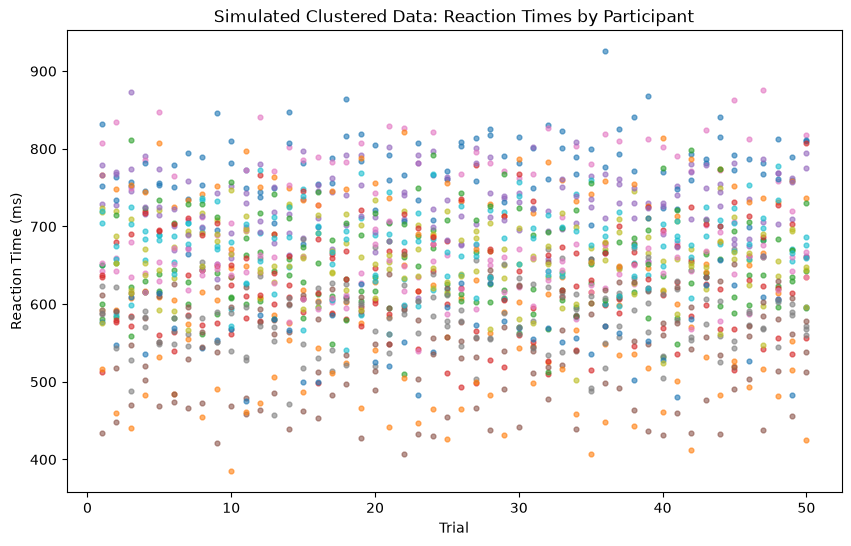

In [8]:
# Visualizing clustered data

plt.figure(figsize=(10, 6))

for participant in range(1, n_participants + 1):

    participant_data = data[data["participant"] == participant]

    plt.scatter(
        participant_data["trial"],
        participant_data["reaction_time"],
        s=12,
        alpha=0.6
    )

plt.xlabel("Trial")
plt.ylabel("Reaction Time (ms)")
plt.title("Simulated Clustered Data: Reaction Times by Participant")

plt.show()

#### Independent and Repeated-Measures data

In [9]:
# Simulation parameters

n_observations = 300

grand_mean = 650

participant_sd = 80

trial_sd = 40

In [10]:
# Dataset 1: independent observations (OLS assumptions are satisfied)

independent_data = pd.DataFrame({
    "reaction_time": np.random.normal(
        loc=grand_mean,
        scale=np.sqrt(participant_sd**2 + trial_sd**2),
        size=n_observations
    )
})

# Dataset 2: repeated-measures observations (OLS assumptions are violated)

n_participants = 30
n_trials = 10

participant_means = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

participant_ids = []
reaction_times = []

for participant in range(n_participants):

    participant_rt = np.random.normal(
        loc=participant_means[participant],
        scale=trial_sd,
        size=n_trials
    )

    participant_ids.extend([participant + 1] * n_trials)
    reaction_times.extend(participant_rt)

repeated_data = pd.DataFrame({
    "participant": participant_ids,
    "reaction_time": reaction_times
})

In [11]:
# Summary statistics

print("Independent dataset\n", independent_data.describe())

print("\nRepeated-measures dataset\n", repeated_data["reaction_time"].describe())

print("\nNumber of participants:", repeated_data["participant"].nunique())

print("\nTrials per participant:", n_trials)

Independent dataset
        reaction_time
count     300.000000
mean      648.466862
std        98.219504
min       400.325655
25%       577.701055
50%       649.078027
75%       718.790338
max       957.026751

Repeated-measures dataset
 count    300.000000
mean     668.813009
std       74.056789
min      508.016777
25%      617.418308
50%      662.586623
75%      715.356118
max      874.605324
Name: reaction_time, dtype: float64

Number of participants: 30

Trials per participant: 10


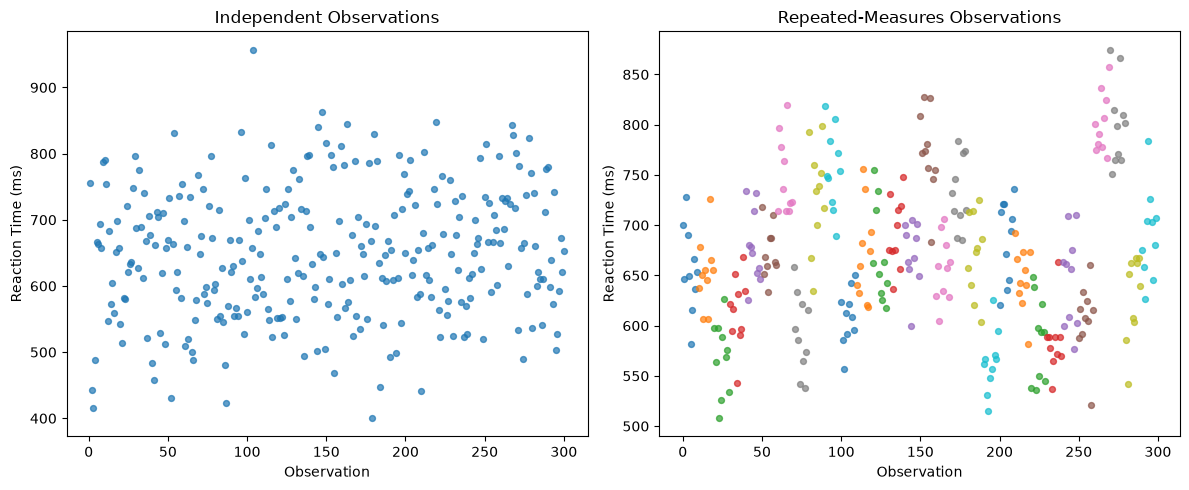

In [12]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Independent observations

axes[0].scatter(
    np.arange(1, n_observations + 1),
    independent_data["reaction_time"],
    alpha=0.7,
    s=18
)

axes[0].set_title("Independent Observations")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Reaction Time (ms)")

# Repeated observations

for participant in range(1, n_participants + 1):

    participant_data = repeated_data[
        repeated_data["participant"] == participant
    ]

    axes[1].scatter(
        participant_data.index,
        participant_data["reaction_time"],
        s=18,
        alpha=0.7
    )

axes[1].set_title("Repeated-Measures Observations")
axes[1].set_xlabel("Observation")
axes[1].set_ylabel("Reaction Time (ms)")

plt.tight_layout()

plt.show()

#### Inflated Type I Error

In [13]:
# Simulation parameters

n_simulations = 1000

n_participants = 30

n_trials = 20

grand_mean = 650

participant_sd = 80

trial_sd = 40

alpha = 0.05

ols_false_positives = 0

participant_false_positives = 0

In [14]:
# Running the simulations.

for simulation in range(n_simulations):

    participant_means = np.random.normal(
        loc=grand_mean,
        scale=participant_sd,
        size=n_participants
    )

    participant_ids = []
    condition = []
    reaction_time = []

    for participant in range(n_participants):

        control_trials = np.random.normal(
            loc=participant_means[participant],
            scale=trial_sd,
            size=n_trials
        )

        experimental_trials = np.random.normal(
            loc=participant_means[participant],
            scale=trial_sd,
            size=n_trials
        )

        participant_ids.extend([participant + 1] * (2 * n_trials))

        condition.extend(["Control"] * n_trials)
        condition.extend(["Experimental"] * n_trials)

        reaction_time.extend(control_trials)
        reaction_time.extend(experimental_trials)

    data = pd.DataFrame({
        "participant": participant_ids,
        "condition": condition,
        "reaction_time": reaction_time
    })

    # Incorrect analysis: OLS assumption of independent observations

    control = data.loc[
        data["condition"] == "Control",
        "reaction_time"
    ]

    experimental = data.loc[
        data["condition"] == "Experimental",
        "reaction_time"
    ]

    _, p_value = ttest_ind(control, experimental)

    if p_value < alpha:
        ols_false_positives += 1

    # Correct participant-level analysis

    participant_means = (
        data
        .groupby(["participant", "condition"])["reaction_time"]
        .mean()
        .unstack()
    )

    participant_difference = (
        participant_means["Experimental"]
        - participant_means["Control"]
    )

    _, p_value = ttest_1samp(
        participant_difference,
        popmean=0
    )

    if p_value < alpha:
        participant_false_positives += 1

In [15]:
# Results

results = pd.DataFrame({
    "Method": [
        "OLS (incorrect)",
        "Participant-level analysis"
    ],
    "False Positive Rate": [
        ols_false_positives / n_simulations,
        participant_false_positives / n_simulations
    ]
})

print("Simulation results\n", results)

print("\nNumber of simulations:", n_simulations)

print("\nParticipants:", n_participants)

print("\nTrials per participant:", n_trials)

Simulation results
                        Method  False Positive Rate
0             OLS (incorrect)                0.000
1  Participant-level analysis                0.052

Number of simulations: 1000

Participants: 30

Trials per participant: 20


#### Linear Regression Models

In [16]:
# Simulating data.

n = 30

memory_load = np.arange(1, n + 1)

reaction_time = (
    450
    + 12 * memory_load
    + np.random.normal(0, 20, n)
)

data = pd.DataFrame({
    "memory_load": memory_load,
    "reaction_time": reaction_time
})

In [17]:
# Manually defining the regression model.

intercept = 450

slope = 12

predicted_rt = intercept + slope * memory_load

# Computing residuals.

residuals = reaction_time - predicted_rt

# Computing residual variance.

residual_variance = np.var(residuals, ddof=1)

# Summary statistics

print("Dataset\n", data.head())

print("\nIntercept:", intercept)

print("\nSlope:", slope)

print("\nResidual variance:", residual_variance)

Dataset
    memory_load  reaction_time
0            1     486.356628
1            2     458.948168
2            3     517.394550
3            4     498.365529
4            5     508.478787

Intercept: 450

Slope: 12

Residual variance: 295.940110370884


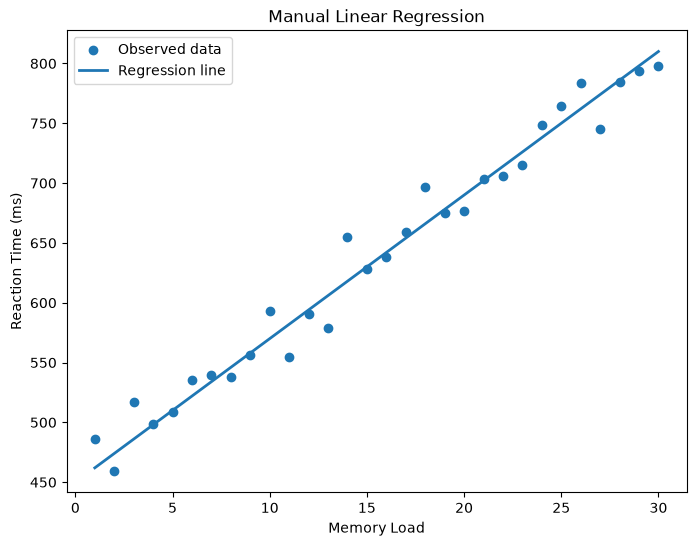

In [18]:
# Visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    memory_load,
    reaction_time,
    label="Observed data"
)

plt.plot(
    memory_load,
    predicted_rt,
    linewidth=2,
    label="Regression line"
)

plt.xlabel("Memory Load")
plt.ylabel("Reaction Time (ms)")
plt.title("Manual Linear Regression")

plt.legend()

plt.show()

#### Linear Regression In Matrix Notation

In [19]:
# Simulating data.

n = 30

memory_load = np.arange(1, n + 1)

reaction_time = (
    450
    + 12 * memory_load
    + np.random.normal(0, 20, n)
)

In [20]:
# Creating the response vector (Y).

Y = reaction_time.reshape(-1, 1)

# Creating the design matrix (X).

X = np.column_stack((
    np.ones(n),
    memory_load
))

# Creating the coefficient vector (beta).

beta = np.array([
    [450],
    [12]
])

# Computing predicted values.

predicted_rt = X @ beta

# Computing residuals.

residuals = Y - predicted_rt

# Creating a results table.

results = pd.DataFrame({
    "memory_load": memory_load,
    "observed_rt": Y.flatten(),
    "predicted_rt": predicted_rt.flatten(),
    "residual": residuals.flatten()
})

In [21]:
# Summary statistics

print("Design matrix (first five rows)\n")
print(X[:5])

print("\nCoefficient vector\n")
print(beta)

print("\nResponse vector (first five observations)\n")
print(Y[:5])

print("\nRegression results\n")
print(results.head())

Design matrix (first five rows)

[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

Coefficient vector

[[450]
 [ 12]]

Response vector (first five observations)

[[450.61001476]
 [468.81070875]
 [487.09211913]
 [486.63867882]
 [532.80066712]]

Regression results

   memory_load  observed_rt  predicted_rt   residual
0            1   450.610015         462.0 -11.389985
1            2   468.810709         474.0  -5.189291
2            3   487.092119         486.0   1.092119
3            4   486.638679         498.0 -11.361321
4            5   532.800667         510.0  22.800667


#### Fixed and Random Effects

In [22]:
# Simulation parameters

n_participants = 6

x = np.linspace(0, 10, 50)

population_intercept = 500

population_slope = 25

participant_intercepts = np.random.normal(
    loc=population_intercept,
    scale=40,
    size=n_participants
)

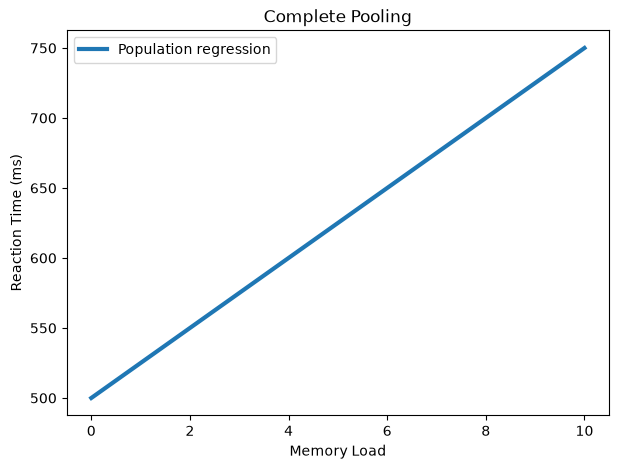

In [23]:
# Figure 1: complete pooling

plt.figure(figsize=(7, 5))

y = population_intercept + population_slope * x

plt.plot(
    x,
    y,
    linewidth=3,
    label="Population regression"
)

plt.xlabel("Memory Load")
plt.ylabel("Reaction Time (ms)")
plt.title("Complete Pooling")

plt.legend()

plt.show()

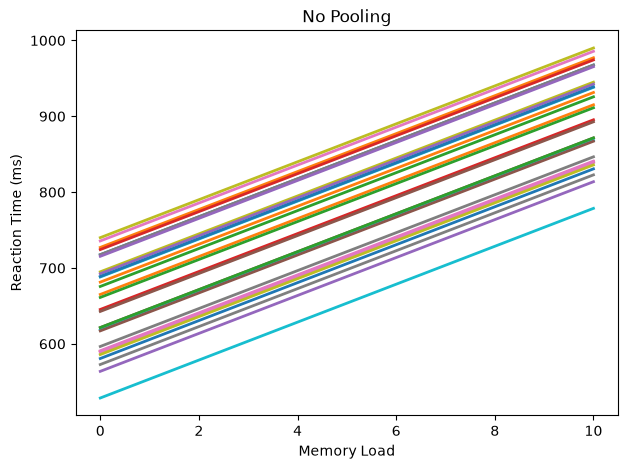

In [38]:
# Figure 2: no pooling

plt.figure(figsize=(7, 5))

for intercept in participant_intercepts:

    y = intercept + population_slope * x

    plt.plot(
        x,
        y,
        linewidth=2
    )

plt.xlabel("Memory Load")
plt.ylabel("Reaction Time (ms)")
plt.title("No Pooling")

plt.show()

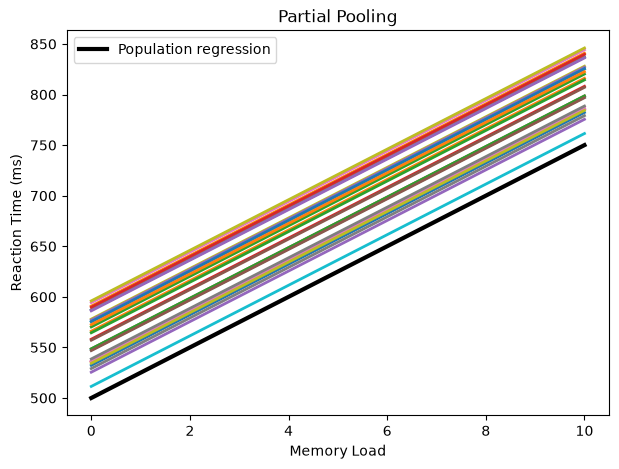

In [39]:
# Figure 3: partial pooling

plt.figure(figsize=(7, 5))

# Population regression

population_line = population_intercept + population_slope * x

plt.plot(
    x,
    population_line,
    color="black",
    linewidth=3,
    label="Population regression"
)

# Participant regressions after shrinkage

shrinkage = 0.40

for intercept in participant_intercepts:

    pooled_intercept = (
        population_intercept
        + shrinkage * (intercept - population_intercept)
    )

    y = pooled_intercept + population_slope * x

    plt.plot(
        x,
        y,
        linewidth=2
    )

plt.xlabel("Memory Load")
plt.ylabel("Reaction Time (ms)")
plt.title("Partial Pooling")

plt.legend()

plt.show()

#### A Repeated-Measures Reaction-Time Experiment Using OLS

In [26]:
# Simulation parameters

n_participants = 30

n_trials_per_condition = 20

grand_mean = 650

stroop_effect = 70

participant_sd = 70

trial_sd = 35

In [27]:
# Simulating participant-specific mean reaction times.

participant_intercepts = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

In [28]:
# Simulating repeated observations.

participant = []

condition = []

reaction_time = []

for i in range(n_participants):

    control_rt = np.random.normal(
        loc=participant_intercepts[i],
        scale=trial_sd,
        size=n_trials_per_condition
    )

    incongruent_rt = np.random.normal(
        loc=participant_intercepts[i] + stroop_effect,
        scale=trial_sd,
        size=n_trials_per_condition
    )

    participant.extend([i + 1] * (2 * n_trials_per_condition))

    condition.extend(
        ["Congruent"] * n_trials_per_condition +
        ["Incongruent"] * n_trials_per_condition
    )

    reaction_time.extend(control_rt)

    reaction_time.extend(incongruent_rt)

In [29]:
# Creating the dataset.

data = pd.DataFrame({
    "participant": participant,
    "condition": condition,
    "reaction_time": reaction_time
})

# Fitting an ordinary least squares regression.

model = smf.ols(
    "reaction_time ~ C(condition)",
    data=data
).fit()

# Printing results.

print("Dataset\n", data.head())

print("\nOLS Regression Summary\n")

print(model.summary())

# Computing participant means.

participant_means = (
    data
    .groupby(["participant", "condition"])["reaction_time"]
    .mean()
    .unstack()
)

Dataset
    participant  condition  reaction_time
0            1  Congruent     693.105630
1            1  Congruent     649.002346
2            1  Congruent     683.509775
3            1  Congruent     741.194794
4            1  Congruent     727.879216

OLS Regression Summary

                            OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     324.9
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           1.88e-64
Time:                        19:49:23   Log-Likelihood:                -6788.5
No. Observations:                1200   AIC:                         1.358e+04
Df Residuals:                    1198   BIC:                         1.359e+04
Df Model:                           1                                         
Covarianc

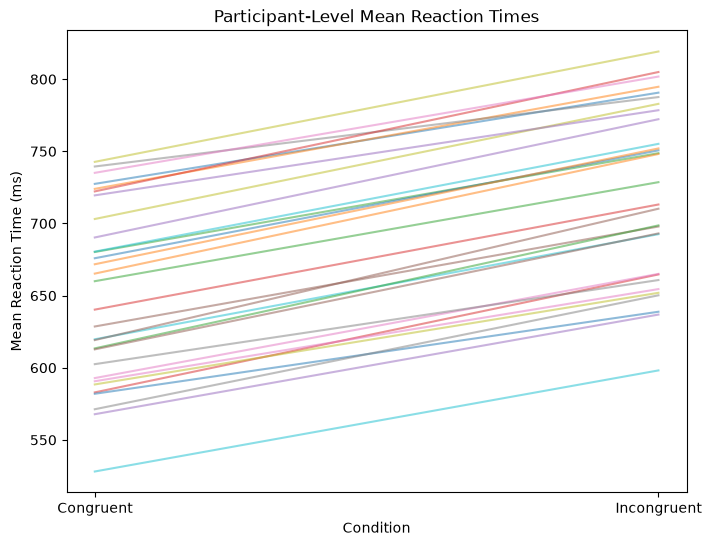

In [30]:
# Visualization

plt.figure(figsize=(8, 6))

for i in participant_means.index:

    plt.plot(
        ["Congruent", "Incongruent"],
        participant_means.loc[i],
        alpha=0.5
    )

plt.xlabel("Condition")
plt.ylabel("Mean Reaction Time (ms)")
plt.title("Participant-Level Mean Reaction Times")

plt.show()